# RQ1 — Dissemination Landscape

**Research Question:** What are the quantitative characteristics and disciplinary distributions of scientific paper mentions on Bluesky?

---

**Part 1 — Scale and Speed**

Question: What is the scale and temporal pattern of science paper sharing on Bluesky?
Output: Figure 1 (daily growth), Figure 2 (monthly), Figure 3 (cumulative), Table 2 (top venues)
Dataset: `science_posts_unique.parquet` (OpenAlex-validated, March–June 2025)
Columns used: `created_at`, `post_uri`, `doi`
Pipeline: produced by `run_pipeline.py` Stage 1–3 (extract → validate → build)

---

**Part 2 — Subject Breadth**

Question: Which scientific domains and fields are most represented?
Output: Table 1 (domain/field distribution), Figure 6 (domain over time)
Dataset: `science_posts_unique.parquet` + OpenAlex API enrichment
Columns used: `doi`, `openalex_id` → fetches `oa_domain`, `oa_field` via API
Cache: `openalex_domain_field_cache.parquet` (avoids repeated API calls)

---

**Part 3 — Benchmark Comparison (pending)**

Question: How does Bluesky compare to other platforms in science paper sharing?
Output: Figure 7 (cross-platform totals), Figure 8 (platform x domain heatmap)
Dataset: `altmetrics.parquet` (not yet available — cells skip gracefully)
Columns needed: `doi`, `cited_by_bluesky_count`, `cited_by_tweeters_count`, `cited_by_msm_count`, `cited_by_rdts_count`

---

**References:**
- Arroyo-Machado, Robinson-Garcia & Torres-Salinas (2025). *Journal of Informetrics*.
- Fang, Mejlgaard & Sorensen (2022). *Scientometrics* 127(8).
- Haustein, Costas & Lariviere (2015). *PLOS ONE* 10(3):e0120495.
- Priem, Taraborelli, Groth & Neylon (2010). Altmetrics: a manifesto.
- Sugimoto et al. (2017). *eLife* 6:e21.
- Zheng et al. (2025). How is science discussed on Bluesky? arXiv:2507.18840.

## Setup

In [19]:
import re
import time
import warnings
from pathlib import Path
from textwrap import wrap
from typing import Any, Optional
from urllib.parse import unquote

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import requests

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
INPUT      = Path('D:/sciencebluesky/final_dataset/science_posts_unique.parquet')
OUTPUT_DIR = Path('D:/sciencebluesky/analysis/RQ1')
CACHE_PATH = Path('D:/sciencebluesky/cache/openalex_domain_field_cache.parquet')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Date range (Firehose window: March–June 2025) ───────────────────────────
START = pd.Timestamp('2025-03-01', tz='UTC')
END   = pd.Timestamp('2025-06-30', tz='UTC') + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

MONTH_LABELS = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

# ── Publication-ready plot style ────────────────────────────────────────────
PALETTE = {
    'Physical Sciences': '#2c5f8a',
    'Health Sciences':   '#c0392b',
    'Life Sciences':     '#27ae60',
    'Social Sciences':   '#e67e22',
    'accent':            '#8e44ad',
    'neutral':           '#7f8c8d',
}
plt.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size':          10,
    'axes.titlesize':     11,
    'axes.titleweight':   'bold',
    'axes.labelsize':     10,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'legend.fontsize':    9,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.linewidth':     0.8,
    'xtick.major.width':  0.8,
    'ytick.major.width':  0.8,
})

def fmt_k(x, _=None):
    if x >= 1_000_000: return f'{x/1e6:.1f}M'
    if x >= 1_000:     return f'{x/1e3:.0f}K'
    return f'{int(x)}'

print('Setup complete.')
print(f'Date window: {START.date()} to {END.date()}')

Setup complete.
Date window: 2025-03-01 to 2025-06-30


## Load & Filter Data

In [20]:
def normalize_doi(value: Any) -> Optional[str]:
    if pd.isna(value): return None
    s = str(value).strip().lower()
    s = re.sub(r'^https?://(?:dx\.)?doi\.org/', '', s)
    s = re.sub(r'^doi:\s*', '', s)
    s = s.split('?')[0].split('#')[0].rstrip('.,;:!?)]}>\'"')
    return s if s else None

df_raw = pd.read_parquet(INPUT)
print(f'Loaded raw: {len(df_raw):,} rows')

if 'openalex_found' in df_raw.columns:
    df_raw = df_raw[df_raw['openalex_found'] == True].copy()
    print(f'After OpenAlex filter: {len(df_raw):,} rows')

df_raw['created_at'] = pd.to_datetime(df_raw['created_at'], errors='coerce', utc=True)
df_raw = df_raw[df_raw['created_at'].notna()].copy()
df = df_raw[(df_raw['created_at'] >= START) & (df_raw['created_at'] <= END)].copy()

assert df['created_at'].dt.month.max() <= 6, 'BUG: July data leaked in!'
print(f'Date range: {df["created_at"].min().date()} to {df["created_at"].max().date()}')

if 'doi' in df.columns:
    df['doi'] = df['doi'].map(normalize_doi)

df['date']        = df['created_at'].dt.date
df['week']        = df['created_at'].dt.to_period('W').dt.start_time
df['month_num']   = df['created_at'].dt.month
df['month']       = df['created_at'].dt.to_period('M').dt.start_time
df['month_label'] = df['month_num'].map(MONTH_LABELS)

total_posts    = len(df)
unique_dois    = df['doi'].nunique() if 'doi' in df.columns else 0
unique_authors = df['user_did'].nunique() if 'user_did' in df.columns else 0

print(f'\nDataset summary:')
print(f'  Total posts:    {total_posts:,}')
print(f'  Unique papers:  {unique_dois:,}')
print(f'  Unique authors: {unique_authors:,}')

Loaded raw: 119,227 rows
After OpenAlex filter: 119,227 rows
Date range: 2025-03-01 to 2025-06-30

Dataset summary:
  Total posts:    115,789
  Unique papers:  82,154
  Unique authors: 29,971


In [34]:
import pandas as pd

pub_links = pd.read_parquet(
    "D:/sciencebluesky/final_dataset/publication_link_candidate_posts.parquet"
)

total_candidate_rows = len(pub_links)
unique_candidate_posts = pub_links["post_uri"].nunique()

print("Total publication-link candidate rows:", total_candidate_rows)
print("Unique publication-link candidate posts:", unique_candidate_posts)

Total publication-link candidate rows: 666309
Unique publication-link candidate posts: 479073


---
## Part 1 — Scale and Speed

**Question:** What is the scale and temporal pattern of science paper sharing on Bluesky?

**Figures:**
- Figure 1 — Daily growth curve with 7-day rolling average
- Figure 2 — Monthly posts vs unique papers
- Figure 3 — Cumulative unique papers over time
- Table 2 — Top venues by posting volume

**Reference:** Zheng et al. (2025); Fang, Mejlgaard & Sorensen (2022).

### 1.1 Summary Statistics

In [21]:
daily = df.groupby('date').size().reset_index(name='posts')
daily['date'] = pd.to_datetime(daily['date'])
peak_row = daily.loc[daily['posts'].idxmax()]

paper_shares = df.groupby('doi').size() if 'doi' in df.columns else pd.Series([1])

print('=== Scale Summary ===')
print(f'Total science posts:          {total_posts:,}')
print(f'Unique scholarly articles:    {unique_dois:,}')
print(f'Unique Bluesky users posting: {unique_authors:,}')
print(f'Average posts per day:        {daily["posts"].mean():.0f}')
print(f'Peak day:                     {peak_row["date"].date()}  ({int(peak_row["posts"]):,} posts)')
print(f'Papers shared >1 time:        {(paper_shares > 1).sum():,} ({(paper_shares > 1).sum()/unique_dois*100:.1f}%)')
print(f'Most shared paper:            {paper_shares.idxmax()} ({paper_shares.max():,} posts)')

=== Scale Summary ===
Total science posts:          115,789
Unique scholarly articles:    82,154
Unique Bluesky users posting: 29,971
Average posts per day:        949
Peak day:                     2025-03-13  (1,416 posts)
Papers shared >1 time:        15,808 (19.2%)
Most shared paper:            10.1177/23780231251334160 (162 posts)


### 1.2 Daily Growth Curve (Figure 1)

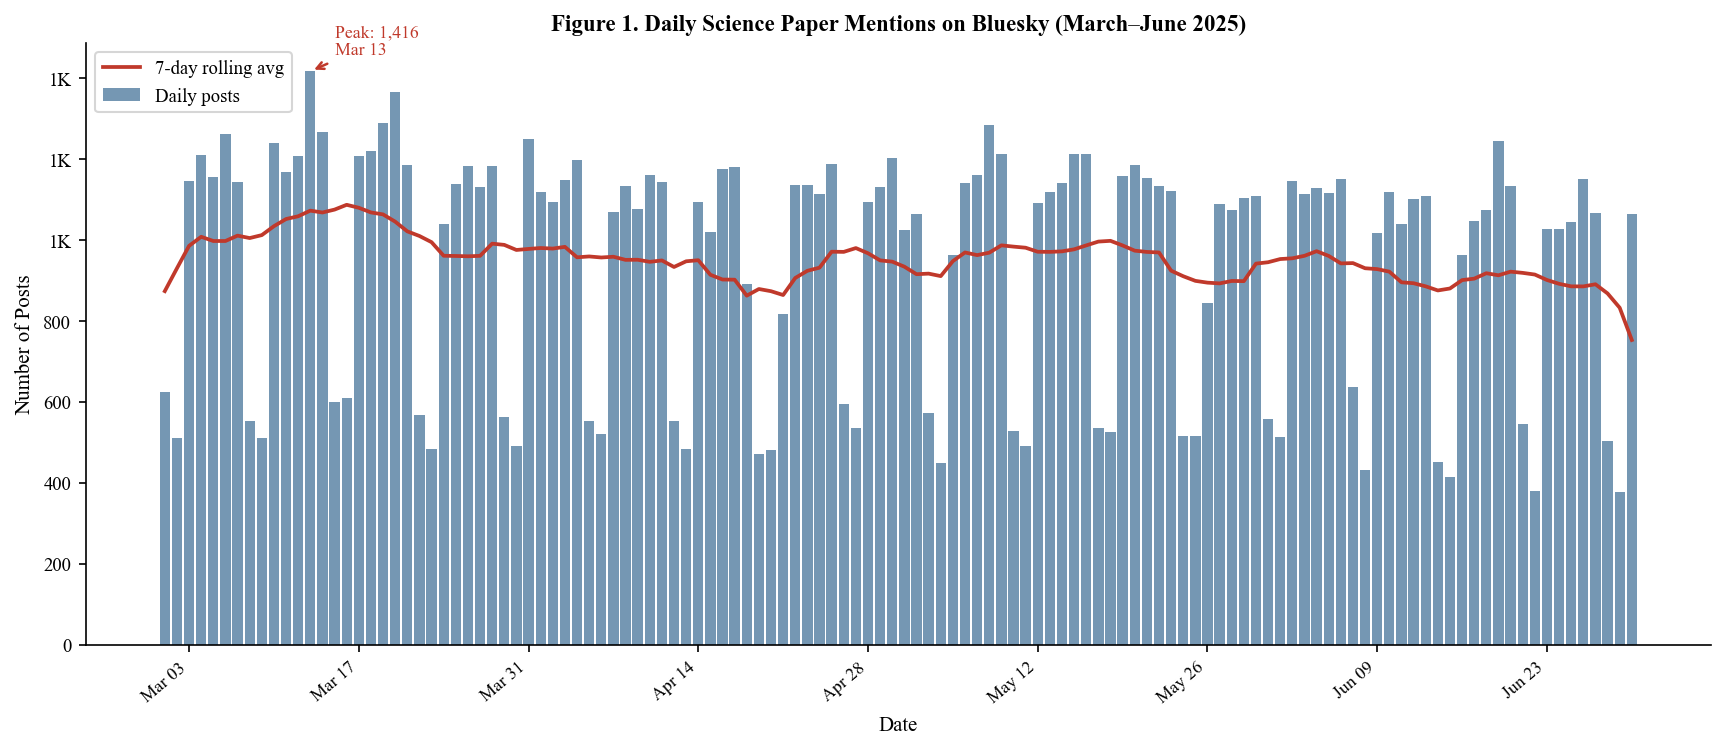

Saved: fig1_growth_curve.pdf / .png


In [22]:
fig, ax1 = plt.subplots(figsize=(12, 5.5))

ax1.bar(daily['date'], daily['posts'],
        color=PALETTE['Physical Sciences'], alpha=0.65,
        width=0.85, label='Daily posts', zorder=2)

daily['roll7'] = daily['posts'].rolling(7, center=True, min_periods=4).mean()
ax1.plot(daily['date'], daily['roll7'],
         color=PALETTE['Health Sciences'], linewidth=1.8,
         label='7-day rolling avg', zorder=5)

pk = daily.loc[daily['posts'].idxmax()]
ax1.annotate(
    f'Peak: {int(pk.posts):,}\n{pk.date.strftime("%b %d")}',
    xy=(pk.date, pk.posts), xytext=(12, 8),
    textcoords='offset points', fontsize=8.5,
    color=PALETTE['Health Sciences'],
    arrowprops=dict(arrowstyle='->', color=PALETTE['Health Sciences'], lw=1.2),
)

ax1.set_ylabel('Number of Posts')
ax1.set_xlabel('Date')
ax1.set_title('Figure 1. Daily Science Paper Mentions on Bluesky (March–June 2025)')
ax1.legend(loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=40, ha='right', fontsize=8.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

plt.tight_layout(pad=2.5)
plt.savefig(OUTPUT_DIR / 'fig1_growth_curve.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig1_growth_curve.png', bbox_inches='tight')
plt.show()
print('Saved: fig1_growth_curve.pdf / .png')

### 1.3 Monthly Breakdown (Figure 2)

Monthly summary:
  Mar 2025  posts= 30,901  unique_papers= 23,951
  Apr 2025  posts= 28,497  unique_papers= 21,947
  May 2025  posts= 29,269  unique_papers= 21,593
  Jun 2025  posts= 27,122  unique_papers= 20,563


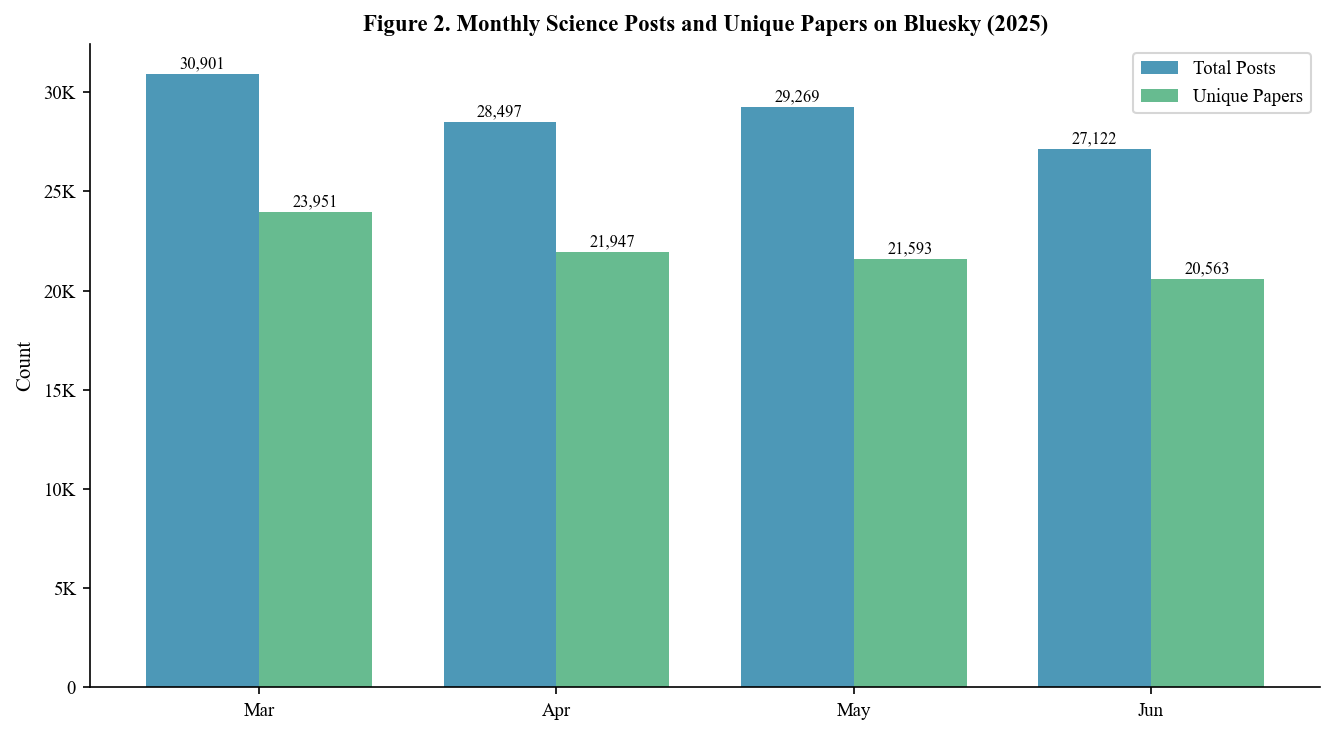

Saved: fig2_monthly_breakdown.pdf / .png


In [23]:
monthly = (
    df.groupby(['month_num', 'month_label'])
    .agg(posts=('doi', 'count'), unique_papers=('doi', 'nunique'))
    .reset_index().sort_values('month_num')
)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(monthly))
w = 0.38
b1 = ax.bar(x - w/2, monthly['posts'],         w, label='Total Posts',   color='#2E86AB', alpha=0.85)
b2 = ax.bar(x + w/2, monthly['unique_papers'], w, label='Unique Papers', color='#4CAF7D', alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(monthly['month_label'])
ax.set_ylabel('Count')
ax.set_title('Figure 2. Monthly Science Posts and Unique Papers on Bluesky (2025)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

print('Monthly summary:')
for _, r in monthly.iterrows():
    print(f"  {r['month_label']} 2025  posts={r['posts']:>7,}  unique_papers={r['unique_papers']:>7,}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_monthly_breakdown.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig2_monthly_breakdown.png', bbox_inches='tight')
plt.show()
print('Saved: fig2_monthly_breakdown.pdf / .png')

### 1.4 Top Venues (Table 2)

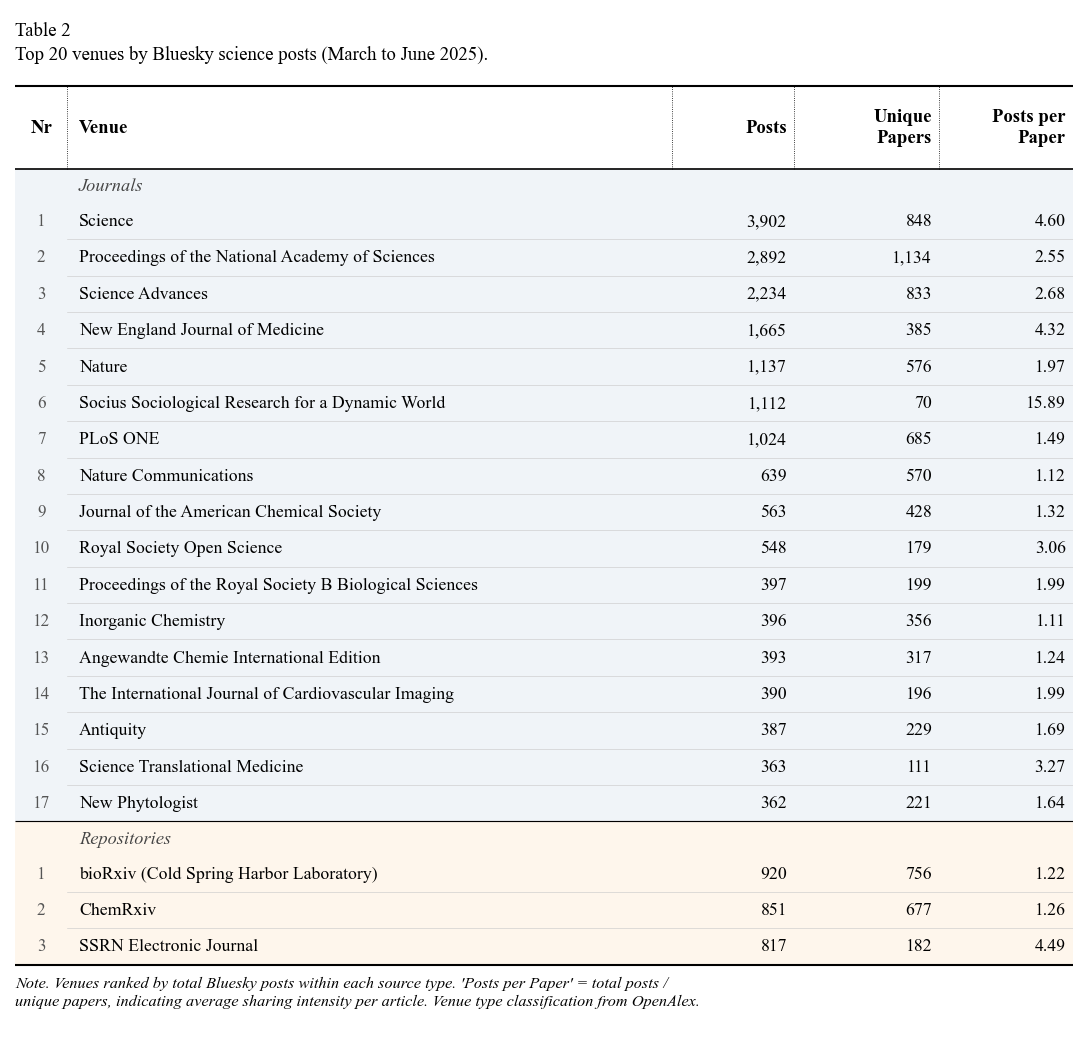

Saved: table2_top_venues.png / .pdf


In [25]:
if 'venue_name' in df.columns and 'venue_type' in df.columns:
    from matplotlib.patches import Rectangle
    from textwrap import wrap as tw_wrap

    top_venues = (
        df[df['venue_name'].notna()]
        .groupby(['venue_name', 'venue_type'])
        .agg(posts=('doi', 'count'), papers=('doi', 'nunique'))
        .sort_values('posts', ascending=False)
        .head(20).reset_index()
    )

    TYPE_ORDER  = ['journal', 'repository', 'conference']
    TYPE_LABELS = {'journal': 'Journals', 'repository': 'Repositories',
                   'conference': 'Conference Proceedings'}
    TYPE_BG     = {'journal': '#f0f4f8', 'repository': '#fef6ec', 'conference': '#f0faf2'}

    tv = top_venues.copy()
    tv['venue_type_lower'] = tv['venue_type'].str.lower()
    tv['ppp'] = tv['posts'] / tv['papers'].replace(0, np.nan)

    flat = []
    for t in TYPE_ORDER:
        sub = tv[tv['venue_type_lower'] == t].sort_values('posts', ascending=False)
        if sub.empty: continue
        flat.append({'kind': 'sep', 'type': t})
        for rank, (_, r) in enumerate(sub.iterrows(), 1):
            flat.append({'kind': 'data', 'type': t, 'rank': rank,
                         'venue': str(r['venue_name']), 'posts': int(r['posts']),
                         'papers': int(r['papers']), 'ppp': r['ppp']})
    N = len(flat)

    COL_W  = [0.45, 5.20, 1.05, 1.25, 1.15]
    TOTAL_W = sum(COL_W)
    xs = [sum(COL_W[:i]) for i in range(len(COL_W)+1)]
    ROW_H, SEP_H, HDR_H, CAP_H, NOTE_H = 0.315, 0.295, 0.72, 0.62, 0.55
    tbl_data_h = sum(SEP_H if r['kind']=='sep' else ROW_H for r in flat)
    FIG_H = CAP_H + HDR_H + tbl_data_h + NOTE_H + 0.12

    fig, ax = plt.subplots(figsize=(TOTAL_W, FIG_H))
    ax.set_xlim(0, TOTAL_W); ax.set_ylim(0, FIG_H); ax.axis('off')

    ax.text(0, FIG_H-0.06,
            'Table 2\nTop 20 venues by Bluesky science posts (March to June 2025).',
            ha='left', va='top', fontsize=9, linespacing=1.4)

    tbl_top = FIG_H - CAP_H
    def hline(y, lw=0.8):
        ax.plot([0, TOTAL_W], [y, y], color='black', linewidth=lw, solid_capstyle='butt', zorder=5)

    hline(tbl_top, lw=1.0)
    hline(tbl_top - HDR_H, lw=0.8)

    hdr_cy = tbl_top - HDR_H / 2
    for label, align, x0, x1 in zip(
            ['Nr','Venue','Posts','Unique\nPapers','Posts per\nPaper'],
            ['center','left','right','right','right'], xs[:-1], xs[1:]):
        xpos = (x0+x1)/2 if align=='center' else (x1-0.06 if align=='right' else x0+0.10)
        ax.text(xpos, hdr_cy, label, ha=align, va='center',
                fontsize=9, fontweight='bold', linespacing=1.3)
    for x in xs[1:-1]:
        ax.plot([x,x],[tbl_top-HDR_H,tbl_top], color='black', lw=0.4, linestyle=':',zorder=4)

    y_cursor = tbl_top - HDR_H
    prev_type = None
    for ri, row in enumerate(flat):
        rh = SEP_H if row['kind']=='sep' else ROW_H
        y_top, y_bot, y_mid = y_cursor, y_cursor-rh, y_cursor-rh/2
        ax.add_patch(Rectangle((0,y_bot), TOTAL_W, rh,
                               facecolor=TYPE_BG.get(row['type'],'white'), edgecolor='none', zorder=0))
        if row['kind'] == 'sep':
            if prev_type is not None: hline(y_top, lw=0.55)
            ax.text(xs[1]+0.10, y_mid, TYPE_LABELS.get(row['type'], row['type']),
                    ha='left', va='center', fontsize=8.8, style='italic', color='#444444')
        else:
            ax.text((xs[0]+xs[1])/2, y_mid, str(row['rank']),
                    ha='center', va='center', fontsize=8.3, color='#555555')
            ax.text(xs[1]+0.10, y_mid, row['venue'], ha='left', va='center', fontsize=8.5)
            ax.text(xs[2]+COL_W[2]-0.06, y_mid, f"{row['posts']:,}",
                    ha='right', va='center', fontsize=8.5)
            ax.text(xs[3]+COL_W[3]-0.06, y_mid, f"{row['papers']:,}",
                    ha='right', va='center', fontsize=8.5)
            ax.text(xs[4]+COL_W[4]-0.06, y_mid, f"{row['ppp']:.2f}",
                    ha='right', va='center', fontsize=8.5)
            nxt = flat[ri+1] if ri+1 < N else None
            if nxt and nxt['kind']=='data' and nxt['type']==row['type']:
                ax.plot([xs[1],TOTAL_W],[y_bot,y_bot], color='#cccccc', lw=0.3, zorder=3)
        prev_type = row['type']
        y_cursor = y_bot

    hline(y_cursor, lw=1.0)
    note = ("Note. Venues ranked by total Bluesky posts within each source type. "
            "'Posts per Paper' = total posts / unique papers, indicating average "
            "sharing intensity per article. Venue type classification from OpenAlex.")
    ax.text(0, y_cursor-0.10, '\n'.join(tw_wrap(note, width=105)),
            ha='left', va='top', fontsize=7.8, style='italic', linespacing=1.35)

    fig.savefig(OUTPUT_DIR/'table2_top_venues.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
    fig.savefig(OUTPUT_DIR/'table2_top_venues.pdf', bbox_inches='tight', pad_inches=0.05)
    plt.show()
    top_venues.to_csv(OUTPUT_DIR/'table2_top_venues.csv', index=False, encoding='utf-8-sig')
    print('Saved: table2_top_venues.png / .pdf')
else:
    print('[SKIP] venue_name / venue_type columns not present.')

---
## Part 2 — Subject Breadth (OpenAlex)

**Question:** Which scientific domains and fields are most represented in Bluesky science posts?

**Method:** OpenAlex primary_topic API for domain/field classification per DOI.
This is the field standard — Arroyo-Machado et al. (2025) and Zheng et al. (2025)
both use OpenAlex domain/field for Bluesky disciplinary analysis.

**Limitation:** Articles without an OpenAlex primary_topic are excluded from
disciplinary analysis. The unclassified proportion is reported in Table 1.

### 2.1 OpenAlex Domain/Field Enrichment

In [26]:
DOMAIN_ORDER = ['Physical Sciences', 'Health Sciences', 'Life Sciences', 'Social Sciences']
FIELD_ORDER = {
    'Physical Sciences': ['Computer Science', 'Physics and Astronomy', 'Mathematics',
                          'Chemistry', 'Earth and Planetary Sciences', 'Environmental Science',
                          'Engineering', 'Materials Science', 'Energy', 'Chemical Engineering'],
    'Health Sciences':   ['Medicine', 'Health Professions', 'Nursing',
                          'Pharmacology, Toxicology and Pharmaceutics', 'Dentistry', 'Veterinary'],
    'Life Sciences':     ['Biochemistry, Genetics and Molecular Biology',
                          'Agricultural and Biological Sciences', 'Neuroscience',
                          'Immunology and Microbiology'],
    'Social Sciences':   ['Social Sciences', 'Psychology',
                          'Economics, Econometrics and Finance',
                          'Business, Management and Accounting',
                          'Arts and Humanities', 'Decision Sciences'],
}

def normalize_openalex_id(value):
    if pd.isna(value): return None
    s = str(value).strip()
    if s.startswith('https://openalex.org/'): return s.rsplit('/', 1)[-1].upper()
    if re.match(r'^[Ww]\d+$', s): return s.upper()
    return None

def fetch_domain_field_batch(ids, api_key='', max_retries=4):
    if not ids: return []
    params = {'filter': 'openalex:' + '|'.join(ids),
              'per_page': min(100, len(ids)), 'select': 'id,primary_topic'}
    if api_key: params['api_key'] = api_key
    for attempt in range(max_retries):
        try:
            r = requests.get('https://api.openalex.org/works', params=params, timeout=45)
            if r.status_code == 429:
                time.sleep(min(60, 2**attempt + 1)); continue
            r.raise_for_status()
            records = []
            for w in r.json().get('results', []):
                t = w.get('primary_topic') or {}
                records.append({
                    'openalex_id_key': normalize_openalex_id(w.get('id')),
                    'oa_domain': (t.get('domain') or {}).get('display_name'),
                    'oa_field':  (t.get('field')  or {}).get('display_name'),
                })
            return records
        except Exception:
            time.sleep(min(60, 2**attempt + 1))
    return []

def enrich_with_domain_field(df, cache_path, api_key='', batch_size=100):
    if 'openalex_id' not in df.columns:
        print('[WARN] No openalex_id column — domain/field unavailable.')
        df['oa_domain'] = pd.NA; df['oa_field'] = pd.NA
        return df
    df = df.copy()
    df['openalex_id_key'] = df['openalex_id'].map(normalize_openalex_id)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache = (pd.read_parquet(cache_path) if cache_path.exists()
             else pd.DataFrame(columns=['openalex_id_key','oa_domain','oa_field']))
    cached_ids = set(cache['openalex_id_key'].dropna().astype(str))
    needed = sorted(set(df['openalex_id_key'].dropna().astype(str)) - cached_ids)
    if needed:
        print(f'Fetching {len(needed):,} works from OpenAlex API...')
        new_records = []
        for i in range(0, len(needed), batch_size):
            batch = needed[i:i+batch_size]
            new_records.extend(fetch_domain_field_batch(batch, api_key=api_key))
            if (i // batch_size + 1) % 20 == 0:
                print(f'  {min(i+batch_size, len(needed)):,}/{len(needed):,}')
            time.sleep(0.12)
        new_df = pd.DataFrame(new_records)
        cache = pd.concat([cache, new_df], ignore_index=True).drop_duplicates(
            subset=['openalex_id_key'], keep='last')
        cache.to_parquet(cache_path, index=False)
        print(f'Cache updated: {len(cache):,} works.')
    else:
        print('Domain/field fully cached — no API calls needed.')
    cache = cache.drop_duplicates('openalex_id_key', keep='last')
    return df.merge(cache[['openalex_id_key','oa_domain','oa_field']],
                    on='openalex_id_key', how='left')

df = enrich_with_domain_field(df, CACHE_PATH)
cov = df['oa_domain'].notna().sum()
print(f'Domain/field coverage: {cov:,} / {len(df):,} posts ({cov/len(df)*100:.1f}%)')

Domain/field fully cached — no API calls needed.
Domain/field coverage: 115,585 / 115,789 posts (99.8%)


### 2.2 Build Domain/Field Distribution Table

In [27]:
unit_col    = 'doi' if 'doi' in df.columns else 'openalex_id'
article_df  = df.dropna(subset=[unit_col]).drop_duplicates(unit_col).copy()
mask_class  = article_df['oa_domain'].notna() & article_df['oa_field'].notna()
classified  = article_df[mask_class].copy()

total_articles   = article_df[unit_col].nunique()
total_classified = classified[unit_col].nunique()
total_unclass    = total_articles - total_classified
unclass_pct      = total_unclass / total_articles * 100 if total_articles else 0

grouped = (
    classified.groupby(['oa_domain','oa_field'])[unit_col]
    .nunique().reset_index(name='n_articles')
)
domain_rank = {d: i for i, d in enumerate(DOMAIN_ORDER)}
field_rank  = {(d,f): i for d, fs in FIELD_ORDER.items() for i, f in enumerate(fs)}
grouped['_dr'] = grouped['oa_domain'].map(domain_rank).fillna(999).astype(int)
grouped['_fr'] = grouped.apply(lambda r: field_rank.get((r['oa_domain'],r['oa_field']),999), axis=1)
grouped = (grouped.sort_values(['_dr','_fr','n_articles'], ascending=[True,True,False])
                  .drop(columns=['_dr','_fr']).reset_index(drop=True))
grouped['proportion'] = grouped['n_articles'] / total_classified

print(f'Unique articles: {total_articles:,}')
print(f'Classified:      {total_classified:,}')
print(f'Unclassified:    {total_unclass:,} ({unclass_pct:.1f}%)')
print(f'Table 1 footnote: {unclass_pct:.1f}% of articles ({total_unclass:,}) '
      f'could not be classified by OpenAlex domain/field.')
print()
print(grouped.to_string(index=False))

Unique articles: 82,154
Classified:      81,994
Unclassified:    160 (0.2%)
Table 1 footnote: 0.2% of articles (160) could not be classified by OpenAlex domain/field.

        oa_domain                                     oa_field  n_articles  proportion
Physical Sciences                             Computer Science        2612    0.031856
Physical Sciences                        Physics and Astronomy        1564    0.019075
Physical Sciences                                  Mathematics         627    0.007647
Physical Sciences                                    Chemistry        2195    0.026770
Physical Sciences                 Earth and Planetary Sciences        2506    0.030563
Physical Sciences                        Environmental Science        7806    0.095202
Physical Sciences                                  Engineering        3185    0.038844
Physical Sciences                            Materials Science        1849    0.022550
Physical Sciences                                

### 2.3 Table 1 

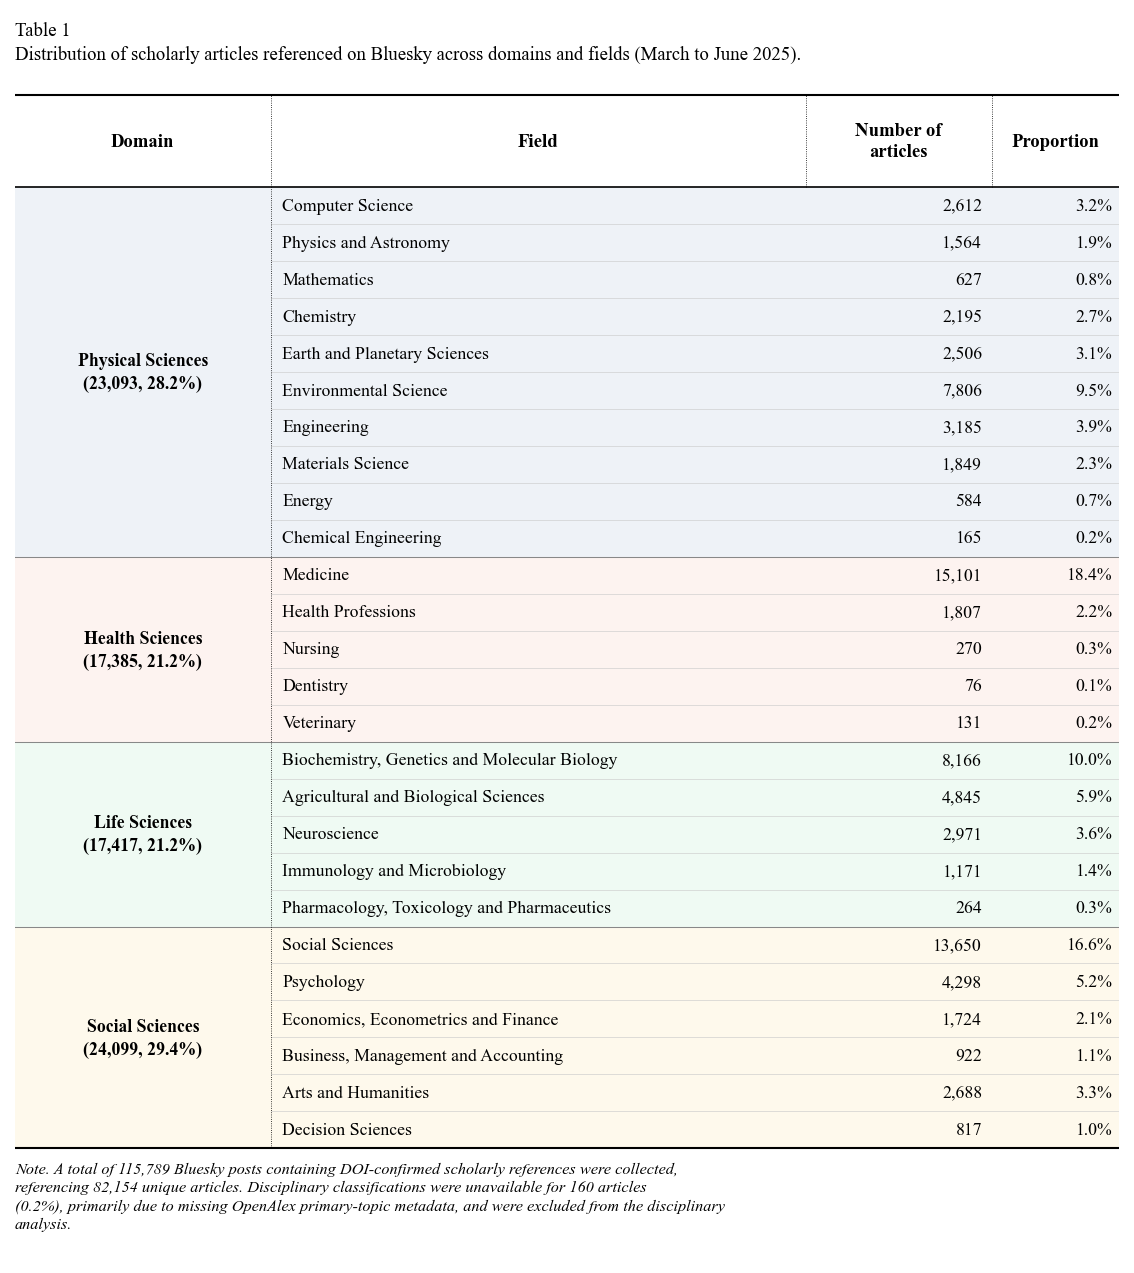

Saved: table1_domain_field.png / .pdf


In [28]:
from matplotlib.patches import Rectangle
from textwrap import wrap as tw_wrap

DOMAIN_COLORS_TBL = {
    'Physical Sciences': '#eef2f7',
    'Health Sciences':   '#fdf3f0',
    'Life Sciences':     '#effaf3',
    'Social Sciences':   '#fef9ec',
}

domain_totals = grouped.groupby('oa_domain')['n_articles'].sum().to_dict()
rows = []
for domain in DOMAIN_ORDER:
    sub = grouped[grouped['oa_domain'] == domain]
    if sub.empty: continue
    d_tot = int(domain_totals.get(domain, 0))
    d_pct = d_tot / total_classified * 100 if total_classified else 0
    first = True
    for _, r in sub.iterrows():
        rows.append(dict(
            domain_label = f"{domain}\n({d_tot:,}, {d_pct:.1f}%)" if first else '',
            field_label  = str(r['oa_field']),
            count_str    = f"{int(r['n_articles']):,}",
            pct_str      = f"{r['n_articles']/total_classified*100:.1f}%",
            domain_block = domain,
            is_first     = first,
        ))
        first = False

plt.rcParams.update({'font.family': 'serif',
                     'font.serif':  ['Times New Roman', 'Times', 'DejaVu Serif'],
                     'font.size':   9})

COL_W   = [2.2, 4.6, 1.6, 1.1]
TOTAL_W = sum(COL_W)
ROW_H   = 0.32; HDR_H = 0.80; CAP_H = 0.70; NOTE_H = 0.80
N       = len(rows)
FIG_H   = CAP_H + HDR_H + N * ROW_H + NOTE_H + 0.15
xs      = [sum(COL_W[:i]) for i in range(len(COL_W)+1)]

fig, ax = plt.subplots(figsize=(TOTAL_W, FIG_H))
ax.set_xlim(0, TOTAL_W); ax.set_ylim(0, FIG_H); ax.axis('off')

ax.text(0, FIG_H - 0.06,
        'Table 1\nDistribution of scholarly articles referenced on Bluesky '
        f'across domains and fields (March to June 2025).',
        ha='left', va='top', fontsize=9, linespacing=1.4)

tbl_top = FIG_H - CAP_H
def hline(y, lw=0.8):
    ax.plot([0, TOTAL_W], [y, y], color='black', linewidth=lw)

hline(tbl_top, lw=1.0)
hline(tbl_top - HDR_H, lw=0.8)
hline(tbl_top - HDR_H - N * ROW_H, lw=1.0)

hdr_y = tbl_top - HDR_H / 2
for label, x0, x1 in zip(['Domain','Field','Number of\narticles','Proportion'], xs[:-1], xs[1:]):
    ax.text((x0+x1)/2, hdr_y, label, ha='center', va='center',
            fontsize=9, fontweight='bold', linespacing=1.3)
for x in xs[1:-1]:
    ax.plot([x,x], [tbl_top - HDR_H, tbl_top], color='black', linewidth=0.4, linestyle=':')

domain_spans = {}
for ri, row in enumerate(rows):
    y_top = tbl_top - HDR_H - ri * ROW_H
    y_bot = y_top - ROW_H
    y_mid = (y_top + y_bot) / 2
    bg    = DOMAIN_COLORS_TBL.get(row['domain_block'], 'white')
    ax.add_patch(Rectangle((xs[1], y_bot), xs[-1]-xs[1], ROW_H,
                            facecolor=bg, edgecolor='none', zorder=0))
    ax.text(xs[1]+0.10, y_mid, row['field_label'], ha='left', va='center', fontsize=8.5)
    ax.text(xs[2]+COL_W[2]-0.08, y_mid, row['count_str'], ha='right', va='center', fontsize=8.5)
    ax.text(xs[3]+COL_W[3]-0.06, y_mid, row['pct_str'],   ha='right', va='center', fontsize=8.5)
    if row['domain_block'] not in domain_spans:
        domain_spans[row['domain_block']] = [y_top, y_bot]
    else:
        domain_spans[row['domain_block']][1] = y_bot
    next_blk = rows[ri+1]['domain_block'] if ri < N-1 else None
    if next_blk == row['domain_block']:
        ax.plot([xs[1], xs[-1]], [y_bot, y_bot], color='#cccccc', linewidth=0.3)
    elif next_blk is not None:
        ax.plot([xs[0], xs[-1]], [y_bot, y_bot], color='#888888', linewidth=0.5)

for domain, (y_top, y_bot) in domain_spans.items():
    d_tot = int(domain_totals.get(domain, 0))
    d_pct = d_tot / total_classified * 100
    ax.add_patch(Rectangle((xs[0], y_bot), xs[1]-xs[0], y_top-y_bot,
                            facecolor=DOMAIN_COLORS_TBL.get(domain,'white'), edgecolor='none', zorder=0))
    ax.text((xs[0]+xs[1])/2, (y_top+y_bot)/2,
            f'{domain}\n({d_tot:,}, {d_pct:.1f}%)',
            ha='center', va='center', fontsize=8.5, fontweight='bold', linespacing=1.4)

ax.plot([xs[1],xs[1]], [tbl_top - HDR_H - N*ROW_H, tbl_top - HDR_H],
        color='black', linewidth=0.4, linestyle=':')

note = (f'Note. A total of {len(df):,} Bluesky posts containing DOI-confirmed '
        f'scholarly references were collected, referencing {total_articles:,} unique '
        f'articles. Disciplinary classifications were unavailable for {total_unclass:,} '
        f'articles ({unclass_pct:.1f}%), primarily due to missing OpenAlex primary-topic '
        f'metadata, and were excluded from the disciplinary analysis.')
ax.text(0, tbl_top - HDR_H - N*ROW_H - 0.12,
        '\n'.join(tw_wrap(note, width=105)),
        ha='left', va='top', fontsize=7.8, style='italic', linespacing=1.35)

fig.savefig(OUTPUT_DIR / 'table1_domain_field.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
fig.savefig(OUTPUT_DIR / 'table1_domain_field.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()
grouped.to_csv(OUTPUT_DIR / 'table1_domain_field.csv', index=False, encoding='utf-8-sig')
print('Saved: table1_domain_field.png / .pdf')

### 2.5 Domain Distribution Over Time (Figure 6)

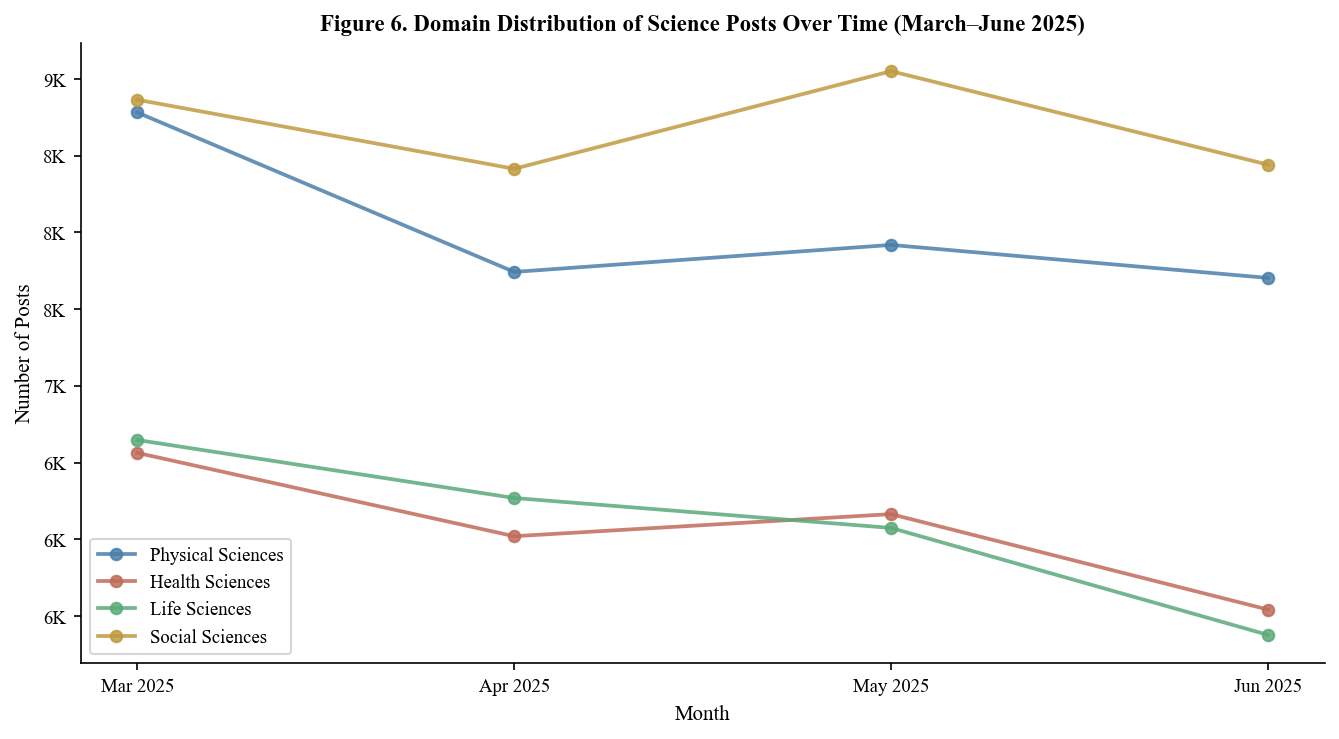

Saved: fig6_domain_over_time.pdf / .png


In [29]:
if 'oa_domain' in df.columns:
    dom_time = (
        df[df['oa_domain'].notna()]
        .groupby(['month_num', 'oa_domain'])
        .size().reset_index(name='posts')
        .sort_values('month_num')
    )
    month_nums        = sorted(dom_time['month_num'].unique())
    month_labels_plot = [MONTH_LABELS[m] + ' 2025' for m in month_nums]

    # Colors matched to Table 1 domain colors — darker shade of the table bg
    DOMAIN_LINE_COLORS = {
        'Physical Sciences': '#4a7faa',   # darker blue — from #eef2f7
        'Health Sciences':   '#c06b5a',   # muted terracotta — from #fdf3f0
        'Life Sciences':     '#5aaa7a',   # muted green — from #effaf3
        'Social Sciences':   '#c09a40',   # muted amber — from #fef9ec
    }

    fig, ax = plt.subplots(figsize=(9, 5))
    for dom in DOMAIN_ORDER:
        sub = dom_time[dom_time['oa_domain'] == dom].sort_values('month_num')
        if sub.empty: continue
        ax.plot(sub['month_num'], sub['posts'],
                marker='o', markersize=5.5, linewidth=1.8,
                label=dom,
                color=DOMAIN_LINE_COLORS.get(dom, PALETTE['neutral']),
                alpha=0.85)

    ax.set_xticks(month_nums)
    ax.set_xticklabels(month_labels_plot, fontsize=9)
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Posts')
    ax.set_title('Figure 6. Domain Distribution of Science Posts Over Time (March–June 2025)')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig6_domain_over_time.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'fig6_domain_over_time.png', bbox_inches='tight')
    plt.show()
    print('Saved: fig6_domain_over_time.pdf / .png')
else:
    print('[SKIP] oa_domain not available.')

---
## Part 3 — Benchmark Comparison (Altmetrics)

> Requires `altmetrics.parquet` with columns: `doi`, `cited_by_bluesky_count`,
> `cited_by_tweeters_count`, `cited_by_msm_count`, `cited_by_rdts_count`.
>
> All Part 3 cells skip gracefully if file is not present.

**Reference:** Priem et al. (2010); Haustein et al. (2015); Sugimoto et al. (2017).

In [30]:
ALT_PATH = Path('D:/sciencebluesky/final_dataset/altmetrics.parquet')

if ALT_PATH.exists():
    alt = pd.read_parquet(ALT_PATH)
    if 'doi' in alt.columns:
        alt['doi'] = alt['doi'].map(normalize_doi)
    print(f'Altmetrics loaded: {len(alt):,} rows')
    print(f'Columns: {list(alt.columns)}')
else:
    alt = None
    print('[INFO] altmetrics.parquet not found — Part 3 cells will be skipped.')

[INFO] altmetrics.parquet not found — Part 3 cells will be skipped.


### 3.1 Cross-Platform Comparison — Overall (Figure 7)

In [31]:
if alt is not None:
    bsky_counts = df.groupby('doi').size().reset_index(name='bsky_posts')
    merged = alt.merge(bsky_counts, on='doi', how='inner')

    platforms = {
        'Bluesky':    'bsky_posts',
        'Twitter/X':  'cited_by_tweeters_count',
        'News media': 'cited_by_msm_count',
        'Reddit':     'cited_by_rdts_count',
    }
    platform_totals = {
        p: merged[col].sum() for p, col in platforms.items() if col in merged.columns
    }

    # Kruskal-Wallis across platforms
    from scipy import stats as sp_stats
    platform_arrays = [merged[col].dropna().values
                       for col in platforms.values() if col in merged.columns]
    if len(platform_arrays) >= 2:
        kw_stat, kw_p = sp_stats.kruskal(*platform_arrays)
        print(f'Kruskal-Wallis across platforms: H={kw_stat:.2f}, p={kw_p:.4f}')

    fig, ax = plt.subplots(figsize=(8, 4.5))
    names = list(platform_totals.keys())
    vals  = list(platform_totals.values())
    colors_plt = [PALETTE['Physical Sciences'], PALETTE['neutral'],
                  PALETTE['Life Sciences'], PALETTE['Social Sciences']]
    bars = ax.bar(names, vals, color=colors_plt[:len(names)], alpha=0.85, edgecolor='white')
    ax.set_ylabel('Total Mentions / Posts')
    ax.set_title('Figure 7. Total Science-Related Mentions by Platform (March–June 2025)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{int(val):,}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig7_platform_comparison.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'fig7_platform_comparison.png', bbox_inches='tight')
    plt.show()
    print('Saved: fig7_platform_comparison.pdf / .png')
else:
    print('[SKIP] Altmetrics data not available.')

[SKIP] Altmetrics data not available.


### 3.2 Cross-Platform Subject Preference Heatmap (Figure 8)

In [32]:
if alt is not None and 'oa_domain' in df.columns:
    dom_bsky = (df[df['oa_domain'].notna()].groupby('oa_domain').size()
                  .rename('bsky_posts').reset_index())
    dom_alt  = alt.merge(df[['doi','oa_domain']].drop_duplicates(), on='doi', how='inner')
    dom_alt  = dom_alt[dom_alt['oa_domain'].notna()]
    platforms_alt = [c for c in ['cited_by_tweeters_count','cited_by_msm_count',
                                  'cited_by_rdts_count'] if c in alt.columns]
    dom_totals_alt = dom_alt.groupby('oa_domain')[platforms_alt].sum().reset_index()

    platform_cols = ['bsky_posts'] + platforms_alt
    platform_names_map = {
        'bsky_posts':              'Bluesky',
        'cited_by_tweeters_count': 'Twitter/X',
        'cited_by_msm_count':      'News',
        'cited_by_rdts_count':     'Reddit',
    }
    heat_df = dom_bsky.merge(dom_totals_alt, on='oa_domain', how='outer').fillna(0)
    heat_df = heat_df[heat_df['oa_domain'].isin(DOMAIN_ORDER)]
    heat_df['oa_domain'] = pd.Categorical(heat_df['oa_domain'],
                                           categories=DOMAIN_ORDER, ordered=True)
    heat_df = heat_df.sort_values('oa_domain')

    mat = heat_df[platform_cols].values.astype(float)

    # Column-normalised (platform share by domain)
    col_sums = mat.sum(axis=0, keepdims=True)
    col_sums[col_sums == 0] = 1
    mat_col_norm = mat / col_sums * 100

    # Row-normalised (domain share by platform) — shows which platform each domain favours
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    mat_row_norm = mat / row_sums * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    for ax, mat_norm, title_suffix in [
        (axes[0], mat_col_norm, 'Column-normalised (% of platform mentions per domain)'),
        (axes[1], mat_row_norm, 'Row-normalised (% of domain mentions per platform)'),
    ]:
        im = ax.imshow(mat_norm.T, aspect='auto', cmap='Blues', vmin=0, vmax=60)
        ax.set_xticks(range(len(DOMAIN_ORDER)))
        ax.set_xticklabels(DOMAIN_ORDER, rotation=20, ha='right')
        ax.set_yticks(range(len(platform_cols)))
        ax.set_yticklabels([platform_names_map.get(c, c) for c in platform_cols])
        ax.set_title(f'Figure 8. Platform x Domain Share\n{title_suffix}', fontsize=9)
        for i in range(len(platform_cols)):
            for j in range(len(DOMAIN_ORDER)):
                ax.text(j, i, f'{mat_norm[j,i]:.1f}%',
                        ha='center', va='center', fontsize=8.5,
                        color='white' if mat_norm[j,i] > 35 else 'black')
        plt.colorbar(im, ax=ax, label='Share (%)', shrink=0.8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig8_platform_domain_heatmap.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'fig8_platform_domain_heatmap.png', bbox_inches='tight')
    plt.show()
    print('Saved: fig8_platform_domain_heatmap.pdf / .png')
else:
    print('[SKIP] Altmetrics or domain data not available.')

[SKIP] Altmetrics or domain data not available.


---
## Summary of Outputs

| Figure / Table | Question answered | Status |
|----------------|-------------------|--------|
| Figure 1 | Daily posting volume + trend | Runs always |
| Figure 2 | Monthly posts vs unique papers | Runs always |
| Figure 3 | Cumulative unique papers over time | Runs always |
| Table 2 | Top 20 venues by posting volume | Runs if venue_name present |
| Table 1 | Domain/field distribution | Runs if OpenAlex enriched |
| Figure 6 | Domain distribution over time | Runs if OpenAlex enriched |
| Figure 7 | Cross-platform mention totals | Runs when altmetrics.parquet available |
| Figure 8 | Platform x domain heatmap (2 panels) | Runs when altmetrics.parquet available |

In [33]:
print('=== RQ1 Analysis Complete ===')
print(f'Output directory: {OUTPUT_DIR}')
print()
print('Figures:')
for f in sorted(OUTPUT_DIR.glob('fig*.png')): print(f'  {f.name}')
print()
print('Tables:')
for f in sorted(OUTPUT_DIR.glob('table*.png')): print(f'  {f.name}')
for f in sorted(OUTPUT_DIR.glob('*.csv')):      print(f'  {f.name}')

=== RQ1 Analysis Complete ===
Output directory: D:\sciencebluesky\analysis\RQ1

Figures:
  fig10_domain_over_time.png
  fig1_growth_curve.png
  fig2_domain_distribution.png
  fig2_monthly_breakdown.png
  fig3_cumulative_growth.png
  fig3_cumulative_papers.png
  fig4_monthly_breakdown.png
  fig4_top_venues.png
  fig5_domain_distribution.png
  fig5_top_papers.png
  fig6_domain_over_time.png
  fig6_top_venues.png
  fig7_open_access.png
  fig8_publication_year.png
  fig9_domain_distribution.png

Tables:
  table1_domain_field.png
  table1_domain_field_distribution.png
  table2_top_venues.png
  supp_top20_papers.csv
  supp_top20_venues.csv
  table1_domain_field.csv
  table1_domain_field_distribution.csv
  table2_top_venues.csv
  top20_papers.csv
  top20_venues.csv
